# From F1 results to a Baku prediction 🏁

Our question: **Who does the model rank highest for the Azerbaijan Grand Prix?**

**Race results → useful clues → learn patterns → test on unseen races → predict Baku**

These are the 6 steps:
1. Our data
2. Understanding our data
3. Feature engineering
4. Training the model
5. Testing the model
6. Interpreting our results

This is an educational **pre-qualifying** model. It uses no qualifying, grid, weather or live laps.

In [1]:
# @title Install the notebook tools
%pip -q install "fastf1>=3.6,<4" "scikit-learn>=1.6,<2" "xgboost>=3.0,<4" matplotlib joblib


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# @title Settings: change these to point the notebook at a different race
TARGET_YEAR = 2026     # season of the race we want to predict
CIRCUIT_ID = 'baku'    # circuit id used by the data source (e.g. 'monza', 'silverstone')
START_YEAR = 2018      # first season loaded. It warms up the features but is not used for training
TEST_YEAR = TARGET_YEAR - 1
assert TARGET_YEAR >= 2022, 'Choose 2022 or later to leave enough training history.'

### Circuit traits
To ask "does this driver excel on street circuits, on fast-corner tracks, or where engine power matters?" the notebook needs to know what each circuit is like. Each circuit gets three tags:

| Tag | Values | Where it comes from |
|---|---|---|
| **street** | street / permanent | hand-labelled (below) |
| **corners** | `fast_corners`, `slow_technical`, `mixed` | hand-labelled (below) |
| **power** | `high`, `medium`, `low` | **measured** from lap telemetry (share of the lap spent flat out) |

The `street` and `corners` labels are **my rough judgement, not official data**. Some circuits are debatable, so edit them and re-run. The `power` tag is measured by the helper script `get_power_index.py` (run it once, see the README), which writes `circuit_power_index.csv`. Until that file exists, the notebook falls back to rough hand-made power ratings and tells you so.

In [3]:
# @title Circuit traits (edit me): circuitId -> (is_street, corners)
from pathlib import Path
import pandas as pd

CIRCUIT_TRAITS = {
    'albert_park': (True, 'mixed'),          'americas': (False, 'mixed'),
    'bahrain': (False, 'mixed'),             'baku': (True, 'slow_technical'),
    'catalunya': (False, 'fast_corners'),    'hungaroring': (False, 'slow_technical'),
    'imola': (False, 'mixed'),               'interlagos': (False, 'mixed'),
    'jeddah': (True, 'fast_corners'),        'losail': (False, 'fast_corners'),
    'marina_bay': (True, 'slow_technical'),  'miami': (True, 'mixed'),
    'monaco': (True, 'slow_technical'),      'monza': (False, 'mixed'),
    'red_bull_ring': (False, 'mixed'),       'ricard': (False, 'mixed'),
    'rodriguez': (False, 'mixed'),           'shanghai': (False, 'mixed'),
    'silverstone': (False, 'fast_corners'),  'spa': (False, 'fast_corners'),
    'suzuka': (False, 'fast_corners'),       'vegas': (True, 'slow_technical'),
    'villeneuve': (True, 'slow_technical'),  'yas_marina': (False, 'mixed'),
    'zandvoort': (False, 'mixed'),           'sochi': (False, 'mixed'),
    'istanbul': (False, 'fast_corners'),     'mugello': (False, 'fast_corners'),
    'nurburgring': (False, 'mixed'),         'portimao': (False, 'mixed'),
    'hockenheimring': (False, 'mixed'),
}

# Rough hand-made power ratings, used ONLY for circuits the telemetry script has not measured.
POWER_FALLBACK = {
    'monza': 'high', 'spa': 'high', 'baku': 'high', 'vegas': 'high', 'red_bull_ring': 'high',
    'sochi': 'high', 'jeddah': 'high', 'villeneuve': 'high', 'rodriguez': 'high', 'hockenheimring': 'high',
    'bahrain': 'medium', 'catalunya': 'medium', 'albert_park': 'medium', 'americas': 'medium',
    'shanghai': 'medium', 'imola': 'medium', 'silverstone': 'medium', 'yas_marina': 'medium',
    'interlagos': 'medium', 'losail': 'medium', 'miami': 'medium', 'istanbul': 'medium',
    'mugello': 'medium', 'ricard': 'medium', 'nurburgring': 'medium', 'portimao': 'medium',
    'suzuka': 'medium', 'monaco': 'low', 'marina_bay': 'low', 'hungaroring': 'low', 'zandvoort': 'low',
}

# Measured power ratings: split circuits into thirds by share of the lap spent flat out.
POWER_LEVEL = dict(POWER_FALLBACK)
power_file = Path('circuit_power_index.csv')
if power_file.exists():
    measured = pd.read_csv(power_file).groupby('circuitId').full_throttle_share.mean()
    low_cut, high_cut = measured.quantile([1 / 3, 2 / 3])
    POWER_LEVEL.update({c: 'high' if v >= high_cut else 'low' if v <= low_cut else 'medium'
                        for c, v in measured.items()})
    print(f'Power tag: measured for {len(measured)} circuits (rest use the hand-made fallback).')
    print((measured.sort_values(ascending=False).map('{:.1%}'.format)).to_string())
else:
    print('Power tag: using the rough hand-made fallback. For measured values run '
          '`python get_power_index.py --before <race date>` and re-run this cell.')

Power tag: measured for 30 circuits (rest use the hand-made fallback).
circuitId
monza            78.2%
jeddah           76.3%
losail           70.5%
spa              69.4%
imola            68.8%
suzuka           67.8%
silverstone      67.2%
albert_park      66.9%
yas_marina       65.8%
red_bull_ring    64.5%
villeneuve       64.1%
portimao         62.6%
sochi            61.8%
catalunya        61.7%
bahrain          61.3%
baku             60.9%
nurburgring      59.1%
americas         59.1%
ricard           59.0%
vegas            58.0%
miami            57.1%
shanghai         56.8%
zandvoort        55.4%
madring          54.3%
marina_bay       53.2%
hungaroring      50.5%
istanbul         50.3%
rodriguez        48.8%
interlagos       45.6%
monaco           40.2%


In [4]:
# @title Prepare tools and helpers (expand only if you're curious :) )
from pathlib import Path
from collections import defaultdict, deque
from datetime import datetime, timezone
import json, time, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import fastf1, sklearn, joblib, xgboost
from fastf1.ergast import Ergast
from xgboost import XGBClassifier
from IPython.display import display

CACHE = Path(f'{CIRCUIT_ID}_cache'); CACHE.mkdir(exist_ok=True)
OUT = Path(f'{CIRCUIT_ID}_outputs'); OUT.mkdir(exist_ok=True)
fastf1.Cache.enable_cache(str(CACHE))
api = Ergast(limit=100)
print('FastF1', fastf1.__version__, '| XGBoost', xgboost.__version__)


# ---------- data download ----------
def retry(fn):
    for attempt in range(4):
        try:
            return fn()
        except Exception:
            if attempt == 3:
                raise
            time.sleep(2 ** (attempt + 1))

def season_results(year):
    path = CACHE / f'results_{year}_{datetime.now(timezone.utc):%Y%m%d}.csv'
    if path.exists():
        return pd.read_csv(path, parse_dates=['raceDate'])
    page = retry(lambda: api.get_race_results(season=year))
    chunks = []
    received = 0
    while True:
        for (_, meta), result in zip(page.description.iterrows(), page.content):
            frame = pd.DataFrame(result).copy()
            for name in ['season', 'round', 'raceDate', 'circuitId', 'raceName']:
                frame[name] = meta[name]
            chunks.append(frame)
            received += len(frame)
        if received >= page.total_results:
            break
        try:
            time.sleep(0.4)
            page = retry(page.get_next_result_page)
        except ValueError as exc:
            if 'No more data' in str(exc):
                break
            raise
    if not chunks:
        return pd.DataFrame()
    frame = pd.concat(chunks, ignore_index=True).drop_duplicates(['season', 'round', 'driverId'])
    frame.to_csv(path, index=False)
    return frame


# ---------- features ----------
BASE_FEATURES = ['driver_finish_5', 'driver_points_5', 'driver_win_rate_5',
                 'driver_podium_rate_5', 'team_points_5', 'team_win_rate_5',
                 'circuit_finish_3', 'circuit_win_rate_3', 'driver_history_count']
EXTRA_FEATURES = ['driver_season_share', 'team_season_share']   # optional, tested in Step 5
TRAIT_NAMES = ['street', 'corners', 'power']
TRAIT_FEATURES = ([f'driver_same_{t}_finish_5' for t in TRAIT_NAMES] +
                  [f'team_same_{t}_points_5' for t in TRAIT_NAMES])   # optional, tested in Step 5
ALL_FEATURES = BASE_FEATURES + EXTRA_FEATURES + TRAIT_FEATURES
FEATURES = BASE_FEATURES        # the feature set the model actually uses

def avg(records, column):
    return float(np.mean([r[column] for r in records])) if records else np.nan

class FormTracker:
    # Remembers recent form. Ask for features() BEFORE a race, call update() AFTER it,
    # so a race can never see its own result.
    def __init__(self):
        self.driver = defaultdict(lambda: deque(maxlen=5))
        self.team = defaultdict(lambda: deque(maxlen=5))
        self.circuit = defaultdict(lambda: deque(maxlen=3))
        self.season = None
        self.driver_pts = defaultdict(float)
        self.team_pts = defaultdict(float)
        self.total_pts = 0.0
        self.driver_type = defaultdict(lambda: deque(maxlen=5))   # (driver, trait) -> last 5 starts on that kind of circuit
        self.team_type = defaultdict(lambda: deque(maxlen=5))     # (team, trait) -> last 5 races on that kind of circuit

    @staticmethod
    def circuit_tags(circuit):
        # e.g. {'street': True, 'corners': 'slow_technical', 'power': 'high'}; missing tags are simply absent
        tags = {}
        if circuit in CIRCUIT_TRAITS:
            tags['street'], tags['corners'] = CIRCUIT_TRAITS[circuit]
        if circuit in POWER_LEVEL:
            tags['power'] = POWER_LEVEL[circuit]
        return tags

    def features(self, driver, team, circuit, season):
        d, t, c = self.driver[driver], self.team[team], self.circuit[(driver, circuit)]
        same_season = (season == self.season) and self.total_pts > 0
        values = [avg(d, 'finish'), avg(d, 'points'), avg(d, 'win'), avg(d, 'podium'),
                  avg(t, 'points'), avg(t, 'win'), avg(c, 'finish'), avg(c, 'win'), len(d),
                  self.driver_pts[driver] / self.total_pts if same_season else np.nan,
                  self.team_pts[team] / self.total_pts if same_season else np.nan]
        tags = self.circuit_tags(circuit)
        values += [avg(self.driver_type[(driver, (n, tags[n]))], 'finish') if n in tags else np.nan for n in TRAIT_NAMES]
        values += [avg(self.team_type[(team, (n, tags[n]))], 'points') if n in tags else np.nan for n in TRAIT_NAMES]
        return dict(zip(ALL_FEATURES, values))

    def update(self, race):
        season = int(race.season.iloc[0])
        if season != self.season:                      # new season: reset the points tables
            self.season, self.total_pts = season, 0.0
            self.driver_pts.clear(); self.team_pts.clear()
        for r in race.itertuples():
            record = dict(finish=float(r.position), points=float(r.points),
                          win=int(r.position == 1), podium=int(r.position <= 3))
            self.driver[r.driverId].append(record)
            self.circuit[(r.driverId, r.circuitId)].append(record)
            self.driver_pts[r.driverId] += float(r.points)
            self.team_pts[r.constructorId] += float(r.points)
            self.total_pts += float(r.points)
        keys = list(self.circuit_tags(race.circuitId.iloc[0]).items())
        for r in race.itertuples():
            for key in keys:
                self.driver_type[(r.driverId, key)].append(dict(finish=float(r.position)))
        for team, team_race in race.groupby('constructorId'):
            self.team[team].append(dict(points=float(team_race.points.sum()),
                                        win=int(team_race.position.eq(1).any())))
            for key in keys:
                self.team_type[(team, key)].append(dict(points=float(team_race.points.sum())))

def build_training_table(history):
    # Returns (training table, tracker). The tracker holds everyone's form up to the
    # last completed race, which is exactly what we need to predict the next one.
    tracker, rows = FormTracker(), []
    for (season, rnd), race in history.groupby(['season', 'round'], sort=True):
        for r in race.itertuples():
            rows.append({**tracker.features(r.driverId, r.constructorId, r.circuitId, int(season)),
                'season': int(season), 'round': int(rnd),
                'race_id': f'{season}-{rnd}', 'raceName': r.raceName,
                'circuitId': r.circuitId, 'driverId': r.driverId,
                'driver': f'{r.givenName} {r.familyName}', 'won': int(r.position == 1), 'top10': int(r.position <= 10)})
        tracker.update(race)
    data = pd.DataFrame(rows)
    return data.loc[data.season > START_YEAR].copy(), tracker


# ---------- model ----------
def new_model():
    return XGBClassifier(n_estimators=120, max_depth=3,
        learning_rate=0.06, reg_lambda=5.0, min_child_weight=5,
        objective='binary:logistic', eval_metric='logloss',
        tree_method='hist', n_jobs=2, random_state=42)

def add_scores(df, raw_scores):
    # Turn raw model outputs into one score per driver that sums to 1 within each race.
    out = df.copy()
    out['raw_score'] = raw_scores
    out['win_score'] = out.raw_score / out.groupby('race_id').raw_score.transform('sum')
    return out

def walk_forward(data, features=None, target='won', first_test_year=2022, last_test_year=None):
    # For each test season Y: train only on seasons before Y, then score season Y.
    # add_scores normalizes each race's scores to sum to 1, which fits a "one winner" target.
    features = features or FEATURES
    last_test_year = last_test_year or TEST_YEAR
    parts = []
    for year in range(first_test_year, last_test_year + 1):
        tr, te = data.loc[data.season < year], data.loc[data.season == year]
        if te.empty:
            continue
        m = new_model().fit(tr[features], tr[target])
        parts.append(add_scores(te, m.predict_proba(te[features])[:, 1]))
    return pd.concat(parts, ignore_index=True)

def walk_forward_raw(data, features, target, score_col, first_test_year=2022, last_test_year=None):
    # Same idea as walk_forward, but keeps the raw predicted probability instead of normalizing
    # it to sum to 1 within each race. Right for a target like "finished top 10", where several
    # drivers can be a "yes" in the same race.
    last_test_year = last_test_year or TEST_YEAR
    parts = []
    for year in range(first_test_year, last_test_year + 1):
        tr, te = data.loc[data.season < year], data.loc[data.season == year]
        if te.empty:
            continue
        m = new_model().fit(tr[features], tr[target])
        te = te.copy()
        te[score_col] = m.predict_proba(te[features])[:, 1]
        parts.append(te)
    return pd.concat(parts, ignore_index=True)

def top10_metrics(scored, score_col):
    # Driver-level log loss/Brier (a proper probabilistic score) plus race-level precision@10:
    # of the model's 10 highest-scored drivers in a race, how many actually finished in the points?
    p = scored[score_col].clip(1e-6, 1 - 1e-6)
    y = scored['top10']
    driver_logloss = float(-(y * np.log(p) + (1 - y) * np.log(1 - p)).mean())
    driver_brier = float(((p - y) ** 2).mean())
    rows = []
    for race_id, g in scored.groupby('race_id', sort=False):
        picked = set(g.sort_values(score_col, ascending=False).head(10).driverId)
        actual = set(g.loc[g.top10 == 1, 'driverId'])
        rows.append(dict(race_id=race_id, field=len(g), precision=len(picked & actual) / 10))
    races = pd.DataFrame(rows)
    return dict(races=races, precision_at_10=float(races.precision.mean()),
                driver_logloss=driver_logloss, driver_brier=driver_brier,
                # what a random 10-driver guess would get right, given each race's actual field size
                # (expected overlap between two random 10-subsets of a field is 10*10/field, so precision is 10/field)
                random_baseline_precision=float((10 / races.field).mean()))

def compare_top10_baselines(scored):
    # Scores the model and some simple rules of thumb on exactly the same races.
    methods = {'XGBoost model': scored.top10_score,
               'Best recent finish': -scored.driver_finish_5.fillna(99),
               'Best recent points': scored.driver_points_5.fillna(-1),
               'Best team form': scored.team_points_5.fillna(-1)}
    rows, random_baseline = [], None
    for name, score in methods.items():
        m = top10_metrics(scored.assign(_s=score), '_s')
        random_baseline = random_baseline or m['random_baseline_precision']
        rows.append({'Method': name, 'Precision@10': f"{m['precision_at_10']:.1%}"})
    rows.append({'Method': 'Random 10 drivers (reference)', 'Precision@10': f'{random_baseline:.1%}'})
    return pd.DataFrame(rows)

def predict_field(field, fitted_model, features=None):
    features = features or FEATURES
    result = field[['driverId', 'driver', 'team']].copy()
    scores = fitted_model.predict_proba(field[features])[:, 1]
    result['win_score'] = scores / scores.sum()
    return result.sort_values('win_score', ascending=False).reset_index(drop=True)


# ---------- evaluation ----------
def race_results(scored, score_col='win_score', with_logloss=False):
    # One row per race. Ties are handled fairly (a k-way tie for first earns 1/k credit),
    # so the order of the rows, which happens to be finishing order, can never leak the answer.
    rows = []
    for race_id, g in scored.groupby('race_id', sort=False):
        s = g[score_col].to_numpy(dtype=float)
        sw = float(g.loc[g.won == 1, score_col].iloc[0])
        greater, equal = int((s > sw).sum()), int((s == sw).sum())
        row = dict(race_id=race_id, season=int(g.season.iloc[0]), field=len(g),
                   top1=(1 / equal) if greater == 0 else 0.0,
                   top3=float(np.clip((3 - greater) / equal, 0, 1)),
                   winner_rank=greater + (equal + 1) / 2)
        if with_logloss:
            row['logloss'] = -np.log(max(sw, 1e-6))
        rows.append(row)
    return pd.DataFrame(rows)

def wilson(p, n, z=1.96):
    # 95% range for a hit rate measured on only n races.
    centre = (p + z * z / (2 * n)) / (1 + z * z / n)
    half = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / (1 + z * z / n)
    return max(0.0, centre - half), min(1.0, centre + half)

def compare_methods(scored):
    # Scores the model and some simple rules of thumb on exactly the same races.
    methods = {'XGBoost model': scored.win_score,
               'Best recent finish': -scored.driver_finish_5.fillna(99),
               'Best recent points': scored.driver_points_5.fillna(-1),
               'Best team form': scored.team_points_5.fillna(-1),
               'Random guess': pd.Series(0.0, index=scored.index)}
    rows, details = [], {}
    for name, score in methods.items():
        pr = race_results(scored.assign(_s=score), '_s', with_logloss=(name == 'XGBoost model'))
        details[name] = pr
        lo, hi = wilson(pr.top1.mean(), len(pr))
        loss = (f'{pr.logloss.mean():.2f}' if name == 'XGBoost model'
                else f'{np.log(pr.field).mean():.2f}' if name == 'Random guess' else '-')
        rows.append({'Method': name, 'Winner picked': f'{pr.top1.mean():.1%}',
                     '95% range': f'{lo:.0%}-{hi:.0%}', 'Winner in top 3': f'{pr.top3.mean():.1%}',
                     'Avg rank of real winner': f'{pr.winner_rank.mean():.1f}', 'Log loss': loss})
    return pd.DataFrame(rows), details

FastF1 3.8.3 | XGBoost 3.4.1


## 1 · Where does the data come from?
FastF1 is the Python tool we use to request F1 results that feed our machine learning model!

In [5]:
schedule = retry(lambda: api.get_race_schedule(season=TARGET_YEAR))
race_rows = schedule.loc[schedule.circuitId.eq(CIRCUIT_ID)]
assert len(race_rows) == 1, 'Choose a season with exactly one race at this circuit.'
target = race_rows.iloc[0]
target_date = pd.Timestamp(target.raceDate).tz_localize(None).normalize()
print(f"Our target: {target.raceName}, {target_date.date()}")

Our target: Azerbaijan Grand Prix, 2026-09-26


In [6]:
# Ask for each season, then combine the results into one table.
frames = [season_results(year) for year in range(START_YEAR, TARGET_YEAR + 1)]
raw = pd.concat(frames, ignore_index=True)
print(f"Downloaded {len(raw):,} driver results.")

Downloaded 3,766 driver results.


## 2 · What does the data look like?
Before modelling anything we keep only races that happened **before** our target race, then run a few sanity checks (no duplicates, exactly one winner per race, no half-empty grids).

In [7]:
# @title Keep eligible races and check the data
raw['raceDate'] = pd.to_datetime(raw['raceDate']).dt.tz_localize(None)
history = raw.loc[raw['raceDate'] < target_date].copy()
history['position'] = pd.to_numeric(history['position'], errors='raise')
history['points'] = pd.to_numeric(history['points'], errors='raise')
history = history.sort_values(['raceDate', 'season', 'round', 'position'])
assert not history.duplicated(['season', 'round', 'driverId']).any()
race_checks = history.groupby(['season', 'round']).agg(
    entrants=('driverId', 'size'), winners=('position', lambda s: s.eq(1).sum()))
assert race_checks['entrants'].ge(18).all(), 'Incomplete race data detected.'
assert race_checks['winners'].eq(1).all(), 'Each race must have exactly one winner.'
assert history['season'].max() == TARGET_YEAR, 'No current-season results. Check data availability.'

unmapped = sorted(set(history.circuitId) - set(CIRCUIT_TRAITS))
if unmapped:
    print('Circuits with no traits yet (their circuit-type clues stay blank):', unmapped)
if CIRCUIT_ID not in CIRCUIT_TRAITS:
    print(f"WARNING: '{CIRCUIT_ID}' has no entry in CIRCUIT_TRAITS, so the target race gets blank circuit-type clues.")

Circuits with no traits yet (their circuit-type clues stay blank): ['madring']


In [8]:
# Find the most recent completed race.
latest_race = history[history.raceDate == history.raceDate.max()]

# Show its top five finishers and the points they earned.
preview = latest_race.sort_values('position')[
    ['raceDate', 'raceName', 'givenName', 'familyName',
     'constructorName', 'position', 'points']
].head(5)
display(preview.reset_index(drop=True))

# Summarize the full dataset used by the notebook.
race_count = history.groupby(['season', 'round']).ngroups
print(f"{race_count} completed races in our dataset")
print(f"Data through {history.raceDate.max().date()}")

,raceDate,raceName,givenName,familyName,constructorName,position,points
0,2026-09-13,Spanish Grand Prix,Andrea Kimi,Antonelli,Mercedes,1,25.0
1,2026-09-13,Spanish Grand Prix,Max,Verstappen,Red Bull,2,18.0
2,2026-09-13,Spanish Grand Prix,Lando,Norris,McLaren,3,15.0
3,2026-09-13,Spanish Grand Prix,Charles,Leclerc,Ferrari,4,12.0
4,2026-09-13,Spanish Grand Prix,George,Russell,Mercedes,5,10.0


187 completed races in our dataset
Data through 2026-09-13


## 3 · What is a feature?
A feature is a clue we give the model. Instead of giving it every old race, we summarize recent performance via features.

### One simple example
If a driver's last five finishes were **2, 1, 4, 3, 5**, their recent average finish would be **3.0**. Lower is better. These are illustrative numbers so you can understand better, not a statement about any real driver.

### Our nine clues, in four groups

| Group | Feature | Meaning |
|---|---|---|
| Driver form | `driver_finish_5` | Average finish over the driver's last 5 starts |
| Driver form | `driver_points_5` | Average points over those starts |
| Driver form | `driver_win_rate_5` | Fraction of those starts won |
| Driver form | `driver_podium_rate_5` | Fraction finished in the top 3 |
| Team form | `team_points_5` | Average combined team points over its last 5 races |
| Team form | `team_win_rate_5` | Fraction of those races won by either team driver |
| Circuit history | `circuit_finish_3` | Average finish over the driver's last 3 starts at this circuit |
| Circuit history | `circuit_win_rate_3` | Fraction of those circuit starts won |
| Available history | `driver_history_count` | Available prior driver starts, capped at 5 |

In training, "this circuit" means the circuit of that historical race. For our forecast, it means **Baku**. If fewer starts exist, we use those available; missing averages stay missing (XGBoost handles gaps natively).

### Optional extra clues (tested in Step 5, off by default)
- `driver_season_share`, `team_season_share`: the share of all championship points scored so far this season. A longer-term view than "last 5 races".
- **Similar-circuit clues** (six of them): how this driver, and separately this team, has done recently on circuits **like the target one**. "Like" means sharing a tag from the circuit-traits table: street or permanent, fast/slow/mixed corners, low/medium/high power. For Baku they look at street circuits, slow-technical circuits and high-power circuits. Because they pool similar tracks, they rest on many more starts than `circuit_finish_3`, which sees at most 3.

Why a team version too? How a car copes with fast corners or long straights is mostly the *car* (aero and engine), not the driver. Giving the model both lets it separate the two.

We compute all of these, but the model only uses them if you add them to `FEATURES`. In Step 5 we test whether they actually help instead of assuming they do.

### Note: Usually there are more features when I share the model the day before the race because I take into account qualifying results and other things like clean-air race pace. Extra pieces of data that we know are good "clues" are among the most important ingredients in building ML models: the more good clues, the better the model can perform.

In [9]:
# Build the full training dataset.
data, tracker = build_training_table(history)

selected_drivers = ['max_verstappen', 'norris', 'leclerc', 'hamilton', 'russell']

# Find each selected driver's most recent example.
selected = data[data['driverId'].isin(selected_drivers)]
latest = (selected.sort_values(['season', 'round'])
          .groupby('driverId', sort=False).tail(1))

print("1. Recent driver form")
display(latest[['driver', 'raceName', 'driver_finish_5', 'driver_points_5',
                'driver_win_rate_5', 'driver_podium_rate_5']].round(2).reset_index(drop=True))

print("2. How one driver's features changed across races")
driver_history = selected[selected['driverId'] == 'max_verstappen'].sort_values(['season', 'round']).tail(5)
display(driver_history[['season', 'raceName', 'driver', 'driver_finish_5',
                        'team_points_5', 'won']].round(2).reset_index(drop=True))

1. Recent driver form


,driver,raceName,driver_finish_5,driver_points_5,driver_win_rate_5,driver_podium_rate_5
0,Max Verstappen,Spanish Grand Prix,10.0,9.6,0.0,0.6
1,Lando Norris,Spanish Grand Prix,3.4,16.0,0.4,0.4
2,Charles Leclerc,Spanish Grand Prix,6.8,13.0,0.2,0.4
3,George Russell,Spanish Grand Prix,7.2,11.4,0.0,0.6
4,Lewis Hamilton,Spanish Grand Prix,4.4,11.4,0.0,0.2


2. How one driver's features changed across races


,season,raceName,driver,driver_finish_5,team_points_5,won
0,2026,Belgian Grand Prix,Max Verstappen,10.2,19.2,0
1,2026,Hungarian Grand Prix,Max Verstappen,10.2,18.8,0
2,2026,Dutch Grand Prix,Max Verstappen,6.2,21.0,0
3,2026,Italian Grand Prix,Max Verstappen,9.8,18.2,0
4,2026,Spanish Grand Prix,Max Verstappen,10.0,16.0,0


### 3b · Who excels on which kind of circuit?
Raw finishing positions mix the driver with the car. To isolate the driver we compare each driver with their **teammate** in the same race: a negative number means they beat their teammate on average. Then we split by circuit tag.

For each tag, the **edge** is the driver's average on the first-named type minus their average on the contrasting type. **A negative edge means relatively better on the first-named type** (street vs permanent, fast corners vs slow technical, high power vs low power). Only drivers with at least 8 starts on both types are shown, and only drivers on the current grid.

Read it as a guide, not a verdict: a few places of edge over ~10-30 races is often just noise, and a retirement counts as a bad finish.

In [10]:
# @title Who excels where? (finish relative to teammate, by circuit tag)
MIN_STARTS = 8
h = history.copy()
h['street'] = h.circuitId.map(lambda c: CIRCUIT_TRAITS.get(c, (None, None))[0])
h['corners'] = h.circuitId.map(lambda c: CIRCUIT_TRAITS.get(c, (None, None))[1])
h['power'] = h.circuitId.map(POWER_LEVEL)

# finish minus the average finish of teammate(s) in the same race
grp = h.groupby(['season', 'round', 'constructorId']).position
team_n, team_sum = grp.transform('size'), grp.transform('sum')
h = h.loc[team_n >= 2].assign(vs_teammate=lambda d: d.position - (team_sum[d.index] - d.position) / (team_n[d.index] - 1))

on_grid = set(history.loc[history.raceDate == history.raceDate.max(), 'driverId'])

def edge_table(tag, first, second):
    d = h.dropna(subset=[tag]).copy()
    d[tag] = d[tag].astype(str)
    g = d.groupby(['driverId', tag]).vs_teammate.agg(['mean', 'size']).reset_index()
    wide = g.pivot(index='driverId', columns=tag, values='mean')
    counts = g.pivot(index='driverId', columns=tag, values='size')
    if first not in wide.columns or second not in wide.columns:
        print(f'  (no circuits tagged both {first!r} and {second!r} yet, so nothing to compare)')
        return pd.DataFrame()
    keep = [drv for drv in wide.index
            if drv in on_grid and counts.loc[drv].get(first, 0) >= MIN_STARTS and counts.loc[drv].get(second, 0) >= MIN_STARTS]
    out = wide.loc[keep, [first, second]].copy()
    out['edge'] = out[first] - out[second]
    out['starts'] = [f"{int(counts.loc[drv, first])} / {int(counts.loc[drv, second])}" for drv in out.index]
    return out.sort_values('edge').round(1).rename(columns={'True': 'street', 'False': 'permanent'})

for tag, first, second, label in [('street', 'True', 'False', 'street vs permanent circuits'),
                                  ('corners', 'fast_corners', 'slow_technical', 'fast corners vs slow technical'),
                                  ('power', 'high', 'low', 'high power vs low power')]:
    print(f'Edge on {label} (negative = relatively better on the first type; starts = first / second)')
    display(edge_table(tag, first, second))

Edge on street vs permanent circuits (negative = relatively better on the first type; starts = first / second)


street,street,permanent,edge,starts
driverId,,,,
antonelli,-0.8,4.2,-5.0,12 / 25
colapinto,-2.2,2.1,-4.3,12 / 28
alonso,-2.5,-1.0,-1.5,43 / 104
ocon,-0.4,0.9,-1.3,43 / 121
piastri,0.4,1.7,-1.3,28 / 55
bottas,0.4,1.5,-1.2,40 / 122
hulkenberg,-0.8,0.2,-0.9,39 / 91
max_verstappen,-4.1,-3.8,-0.3,48 / 138
sainz,-0.3,-0.0,-0.3,47 / 138


Edge on fast corners vs slow technical (negative = relatively better on the first type; starts = first / second)


corners,fast_corners,slow_technical,edge,starts
driverId,,,,
russell,-1.1,1.0,-2.1,43 / 35
leclerc,-0.8,0.9,-1.7,47 / 40
tsunoda,2.9,3.8,-1.0,29 / 26
ocon,-0.5,0.4,-0.9,43 / 35
albon,-0.8,0.0,-0.8,37 / 32
bortoleto,-0.8,0.0,-0.8,10 / 9
norris,-0.8,-0.1,-0.8,43 / 35
bearman,0.5,1.0,-0.5,11 / 10
gasly,-1.6,-1.2,-0.4,47 / 40


Edge on high power vs low power (negative = relatively better on the first type; starts = first / second)


power,high,low,edge,starts
driverId,,,,
leclerc,-1.9,0.7,-2.7,77 / 56
tsunoda,2.0,4.3,-2.4,48 / 38
bortoleto,-1.1,0.4,-1.4,16 / 14
piastri,1.1,2.2,-1.1,35 / 29
stroll,0.9,2.0,-1.1,77 / 56
russell,-1.0,0.1,-1.0,69 / 50
max_verstappen,-4.2,-3.6,-0.6,77 / 56
norris,-1.9,-1.6,-0.3,69 / 50
albon,-1.6,-1.4,-0.3,58 / 44


## 4 · Where do we train the model?
Training means learning patterns from examples where we already know the answer.

First we divide the races in time. For the 2026 forecast, the teaching model learns from **2019-2024** and is tested on **2025**.
We keep whole races together. We do not randomly mix drivers from the same race between train and test.

In [11]:
train = data.loc[data.season < TEST_YEAR]
test = data.loc[data.season == TEST_YEAR].copy()
assert train.race_id.nunique() >= 30 and test.race_id.nunique() >= 10
assert set(train.race_id).isdisjoint(test.race_id)
print(f"TRAIN: {train.season.min()}-{train.season.max()} | {train.race_id.nunique()} races")
print(f"TEST:  {TEST_YEAR} | {test.race_id.nunique()} races")

TRAIN: 2019-2024 | 128 races
TEST:  2025 | 24 races


**Inputs → XGBoost → learned patterns**

XGBoost combines many small decision trees. Each new tree helps correct errors made by the earlier trees.

`X_train` contains the clues. `y_train` contains the winner labels. `.fit()` is the training step.

In [12]:
X_train = train[FEATURES]   # The clues/features
y_train = train['won']      # The known answers

evaluation_model = new_model()
evaluation_model.fit(X_train, y_train)
print("Training complete. Now let's test on races it did not train on.")

Training complete. Now let's test on races it did not train on.


## 5 · How do we test it?
We give the model the test-season clues without the answers, look at how it ranks the drivers in each race, then check who actually won.

We measure four things:
- **Winner picked**: how often the model's #1 driver actually won
- **Winner in top 3**: how often the real winner was among the model's top 3
- **Avg rank of real winner**: on average, where the model placed the driver who won (1 is perfect; a coin-flip over 20 cars gives about 10.5)
- **Log loss**: how much score the model gave the real winner (lower is better). It rewards a model for being *confidently right* and punishes it for being *confidently wrong*

We also run simple rules of thumb ("just pick the driver with the best recent finishes") on the same races. If XGBoost can't beat those, the extra complexity isn't earning its keep.

In [13]:
test = add_scores(test, evaluation_model.predict_proba(test[FEATURES])[:, 1])
report_2025, details_2025 = compare_methods(test)
display(report_2025)

pr = details_2025['XGBoost model']
print(f"Model picked {pr.top1.sum():.0f} winners correctly out of {len(pr)} races.")

metrics = {'test_year': TEST_YEAR, 'test_races': int(len(pr)),
           'winner_accuracy': float(pr.top1.mean()),
           'recent_form_baseline_accuracy': float(details_2025['Best recent finish'].top1.mean())}

,Method,Winner picked,95% range,Winner in top 3,Avg rank of real winner,Log loss
0,XGBoost model,33.3%,18%-53%,75.0%,2.6,1.82
1,Best recent finish,27.1%,13%-47%,70.8%,2.6,-
2,Best recent points,29.2%,15%-49%,68.8%,2.8,-
3,Best team form,22.9%,11%-43%,52.1%,3.7,-
4,Random guess,5.0%,1%-21%,15.0%,10.5,2.99


Model picked 8 winners correctly out of 24 races.


### One season is a small test
A single season is only ~24 races, so a difference of one or two correct picks is mostly luck (see the **95% range** column: it is wide). To get a steadier answer we use **walk-forward testing**: for each season from 2022 onward, train only on the seasons *before* it, then test on it. Every test race is still unseen by its own model, and we get roughly four times as many races to judge on.

In [14]:
wf = walk_forward(data)                       # out-of-sample scores for 2022 ... TEST_YEAR
wf_report, wf_details = compare_methods(wf)
print(f"Walk-forward test: {wf.season.min()}-{wf.season.max()}, {wf.race_id.nunique()} races")
display(wf_report)

by_season = pd.DataFrame({name: pr.groupby('season').top1.mean() for name, pr in wf_details.items()})
shown = by_season.map(lambda v: f'{v:.0%}')
shown.insert(0, 'Races', wf_details['XGBoost model'].groupby('season').size())
print("Winner picked, season by season")
display(shown)

m = wf_details['XGBoost model']
metrics['walk_forward'] = {
    'test_years': [int(wf.season.min()), int(wf.season.max())], 'races': int(len(m)),
    'winner_accuracy': float(m.top1.mean()), 'top3_accuracy': float(m.top3.mean()),
    'avg_winner_rank': float(m.winner_rank.mean()), 'log_loss': float(m.logloss.mean()),
    'random_guess_accuracy': float(wf_details['Random guess'].top1.mean())}

Walk-forward test: 2022-2025, 92 races


,Method,Winner picked,95% range,Winner in top 3,Avg rank of real winner,Log loss
0,XGBoost model,51.1%,41%-61%,75.0%,2.4,1.61
1,Best recent finish,45.7%,36%-56%,70.7%,2.6,-
2,Best recent points,48.9%,39%-59%,74.5%,2.5,-
3,Best team form,29.3%,21%-39%,66.8%,3.0,-
4,Random guess,5.0%,2%-12%,15.0%,10.5,2.99


Winner picked, season by season


,Races,XGBoost model,Best recent finish,Best recent points,Best team form,Random guess
season,,,,,,
2022,22,50%,50%,48%,30%,5%
2023,22,86%,86%,86%,48%,5%
2024,24,38%,23%,35%,19%,5%
2025,24,33%,27%,29%,23%,5%


### Do the extra clues help?
Adding features feels like progress, but it only counts if the walk-forward score improves. This is called an **ablation**: same model, same races, only the clues change.

In [15]:
feature_sets = {'Original 9 clues': BASE_FEATURES,
                '+ season-share clues': BASE_FEATURES + EXTRA_FEATURES,
                '+ similar-circuit clues': BASE_FEATURES + TRAIT_FEATURES,
                '+ both': BASE_FEATURES + EXTRA_FEATURES + TRAIT_FEATURES}
rows = []
for name, cols in feature_sets.items():
    pr = race_results(walk_forward(data, cols), with_logloss=True)
    rows.append({'Clues used': name, 'Winner picked': f'{pr.top1.mean():.1%}',
                 'Winner in top 3': f'{pr.top3.mean():.1%}',
                 'Avg rank of real winner': f'{pr.winner_rank.mean():.2f}',
                 'Log loss': f'{pr.logloss.mean():.3f}'})
display(pd.DataFrame(rows))

,Clues used,Winner picked,Winner in top 3,Avg rank of real winner,Log loss
0,Original 9 clues,51.1%,75.0%,2.42,1.608
1,+ season-share clues,47.8%,73.9%,2.44,1.583
2,+ similar-circuit clues,50.0%,73.9%,2.45,1.622
3,+ both,47.8%,72.8%,2.47,1.595


How to read this: if a row beats the first on log loss **and** rank, set `FEATURES` in the helpers cell to that row's list (for example `BASE_FEATURES + TRAIT_FEATURES`) and re-run from Step 3. If rows are close, keep the simpler one. With ~90 races, small gaps are noise.

### Can we trust the scores as chances?
The model's scores are normalized so each race sums to 100%, but that does **not** make them true probabilities. We can check honestly: group every driver from the walk-forward test by the score the model gave them, then compare with how often those drivers really won.

In [16]:
bins = [0, 0.02, 0.05, 0.10, 0.20, 0.40, 1.0]
wf['score_band'] = pd.cut(wf.win_score, bins, include_lowest=True)
calibration = (wf.groupby('score_band', observed=True)
               .agg(driver_entries=('won', 'size'), avg_model_score=('win_score', 'mean'),
                    actual_win_rate=('won', 'mean')))
display(calibration.assign(avg_model_score=lambda t: t.avg_model_score.map('{:.1%}'.format),
                           actual_win_rate=lambda t: t.actual_win_rate.map('{:.1%}'.format)))

,driver_entries,avg_model_score,actual_win_rate
score_band,,,
"(-0.001, 0.02]",1309,0.5%,0.3%
"(0.02, 0.05]",120,3.3%,8.3%
"(0.05, 0.1]",137,7.3%,5.1%
"(0.1, 0.2]",141,13.7%,12.8%
"(0.2, 0.4]",67,28.0%,22.4%
"(0.4, 1.0]",64,53.0%,59.4%


If the top bands show a model score well above the actual win rate, the model is **overconfident** there. Treat those scores as a *ranking* ("who looks strongest"), not as betting odds.

## 5b · A separate model for the points finishers (top 10)
Predicting the *winner* and predicting *who finishes in the points* are different problems, so this uses its own model: same features, but trained on a different target ("did this driver finish in the top 10?" instead of "did this driver win?"). It gets tested the same honest way, with its own walk-forward test and its own baselines.

**One thing to keep in mind:** F1 fields are usually 18-24 cars, so the top 10 is close to *half* the field. A method that is only mediocre at telling drivers apart can still score well here just because it's a coin flip for many drivers. The **"Random 10 drivers"** row below shows what pure luck would score, so the model's real skill is whatever it adds on top of that, not the raw number.

In [17]:
points_wf = walk_forward_raw(data, FEATURES, 'top10', score_col='top10_score')
points_wf_metrics = top10_metrics(points_wf, 'top10_score')
print(f"Walk-forward points-finisher test: {points_wf.season.min()}-{points_wf.season.max()}, "
      f"{points_wf.race_id.nunique()} races")
print(f"Per-driver log loss: {points_wf_metrics['driver_logloss']:.3f}  |  "
      f"Brier score: {points_wf_metrics['driver_brier']:.3f}  (lower is better on both)")
display(compare_top10_baselines(points_wf))

metrics['points_model'] = {
    'test_years': [int(points_wf.season.min()), int(points_wf.season.max())],
    'races': int(points_wf.race_id.nunique()),
    'precision_at_10': points_wf_metrics['precision_at_10'],
    'random_guess_precision_at_10': points_wf_metrics['random_baseline_precision'],
    'driver_log_loss': points_wf_metrics['driver_logloss'],
    'driver_brier_score': points_wf_metrics['driver_brier']}

Walk-forward points-finisher test: 2022-2025, 92 races
Per-driver log loss: 0.527  |  Brier score: 0.174  (lower is better on both)


,Method,Precision@10
0,XGBoost model,74.5%
1,Best recent finish,72.5%
2,Best recent points,74.9%
3,Best team form,74.9%
4,Random 10 drivers (reference),50.1%


## 6 · What does the model predict for Baku?
The tests told us how this approach performs. Now we train a final copy using all eligible completed races before Baku.

This final fit includes the former test seasons. Its training score is **not** a new test result; the honest results remain the held-out tests above.

In [18]:
model = new_model()
model.fit(data[FEATURES], data['won'])
print("Final model trained on all eligible pre-race examples.")

Final model trained on all eligible pre-race examples.


In [19]:
# @title Prepare the provisional field and its clues
latest = history.loc[history.raceDate.eq(history.raceDate.max())].copy()
entries = latest[['driverId', 'constructorId', 'constructorName', 'givenName', 'familyName']].copy()
entries['driver'] = entries.givenName + ' ' + entries.familyName
entries = entries.rename(columns={'constructorName': 'team'})[['driverId', 'constructorId', 'driver', 'team']]
entry_source = 'Most recent completed race; confirm substitutions'
entries_file = Path(f'{CIRCUIT_ID}_entries.csv')
if entries_file.exists():
    entries = pd.read_csv(entries_file)
    assert {'driverId', 'constructorId', 'driver', 'team'} <= set(entries.columns)
    entry_source = 'User-supplied entry list'
assert entries.driverId.is_unique and len(entries) >= 18
assert entries[['driverId', 'constructorId', 'driver', 'team']].notna().all().all()

# The tracker already knows everyone's form up to the last completed race.
clues = pd.DataFrame([tracker.features(r.driverId, r.constructorId, CIRCUIT_ID, TARGET_YEAR)
                      for r in entries.itertuples()])[FEATURES]
inputs = pd.concat([entries.reset_index(drop=True), clues], axis=1)

In [20]:
predictions = predict_field(inputs, model)
assert np.isclose(predictions.win_score.sum(), 1)
print(f"MODEL TOP PICK: {predictions.iloc[0].driver}")
display(predictions[['driver', 'team', 'win_score']].head(5)
        .assign(win_score=lambda table: table.win_score.map('{:.1%}'.format)))

MODEL TOP PICK: Andrea Kimi Antonelli


,driver,team,win_score
0,Andrea Kimi Antonelli,Mercedes,53.6%
1,Max Verstappen,Red Bull,13.2%
2,Lando Norris,McLaren,10.9%
3,George Russell,Mercedes,7.8%
4,Charles Leclerc,Ferrari,5.5%


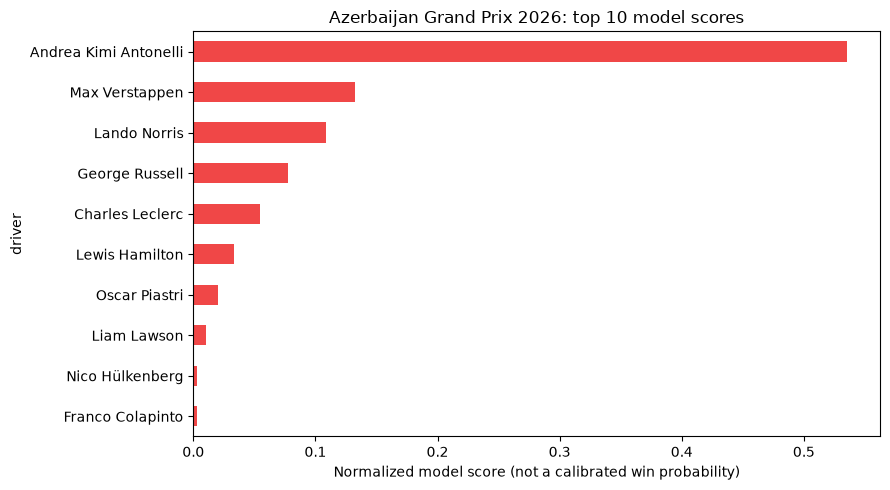

In [21]:
ax = predictions.head(10).sort_values('win_score').plot.barh(
    x='driver', y='win_score', legend=False, color='#F04747', figsize=(9, 5))
ax.set_title(f'{target.raceName} {TARGET_YEAR}: top 10 model scores')
ax.set_xlabel('Normalized model score (not a calibrated win probability)')
plt.tight_layout()
plt.show()

### Predicted points finishers (top 10)
This uses the points-finisher model from Section 5b, trained on every eligible race so far, and ranks the whole field by it. The table also shows each driver's win score for reference. As above, treat `top10_score` as a ranking, not a guaranteed probability: check the calibration and the "Random 10 drivers" reference in Section 5b before trusting a specific number.

In [22]:
points_model = new_model()
points_model.fit(data[FEATURES], data['top10'])

inputs['top10_score'] = points_model.predict_proba(inputs[FEATURES])[:, 1]
points_finishers = (inputs.sort_values('top10_score', ascending=False)
                    .head(10)[['driverId', 'driver', 'team', 'top10_score']]
                    .reset_index(drop=True))
points_finishers.insert(0, 'predicted_position', np.arange(1, 11))
points_finishers['points'] = [25, 18, 15, 12, 10, 8, 6, 4, 2, 1]
points_finishers = points_finishers.merge(predictions[['driverId', 'win_score']], on='driverId', how='left')

print(f"PREDICTED POINTS FINISHERS: {', '.join(points_finishers.driver)}")
display(points_finishers[['predicted_position', 'driver', 'team', 'win_score', 'top10_score', 'points']]
        .assign(win_score=lambda t: t.win_score.map(lambda v: '-' if pd.isna(v) else f'{v:.1%}'),
                top10_score=lambda t: t.top10_score.map('{:.1%}'.format)))

PREDICTED POINTS FINISHERS: Lando Norris, Andrea Kimi Antonelli, Charles Leclerc, Lewis Hamilton, George Russell, Liam Lawson, Max Verstappen, Oscar Piastri, Arvid Lindblad, Franco Colapinto


,predicted_position,driver,team,win_score,top10_score,points
0,1,Lando Norris,McLaren,10.9%,91.2%,25
1,2,Andrea Kimi Antonelli,Mercedes,53.6%,89.0%,18
2,3,Charles Leclerc,Ferrari,5.5%,83.5%,15
3,4,Lewis Hamilton,Ferrari,3.3%,83.2%,12
4,5,George Russell,Mercedes,7.8%,80.4%,10
5,6,Liam Lawson,Red Bull,1.1%,78.9%,8
6,7,Max Verstappen,Red Bull,13.2%,78.6%,6
7,8,Oscar Piastri,McLaren,2.0%,71.4%,4
8,9,Arvid Lindblad,RB F1 Team,0.1%,35.8%,2
9,10,Franco Colapinto,Alpine F1 Team,0.3%,32.1%,1


These scores help rank the field. A 50% model score does not mean there is a proven 50% chance of winning (see the calibration table above).

The model cannot see qualifying, weather, tyre strategy, accidents, or other data that is very valuable and arguably more important until race weekend begins. It also learns mostly from past regulation eras, so a season with new rules (like 2026) is harder to predict than a stable one.

In [23]:
# @title Save the model, its results and the dashboard kit
payload = {
    'race': target.raceName, 'circuit': CIRCUIT_ID, 'year': TARGET_YEAR,
    'model_type': 'XGBClassifier', 'xgboost_version': xgboost.__version__,
    'features': FEATURES,
    'race_date': target_date.date().isoformat(),
    'generated_at': datetime.now(timezone.utc).isoformat(),
    'data_through': history.raceDate.max().date().isoformat(),
    'entry_source': entry_source, 'mode': 'pre_qualifying',
    'score_label': 'Normalized model score; not a calibrated win probability',
    'model_pick': predictions.iloc[0].driver,
    'evaluation': metrics, 'predictions': predictions.to_dict(orient='records'),
    'points_predictions': points_finishers.to_dict(orient='records')}
(OUT / f'{CIRCUIT_ID}_predictions.json').write_text(json.dumps(payload, indent=2, allow_nan=False))
inputs.to_json(OUT / f'{CIRCUIT_ID}_inputs.json', orient='records', indent=2)
predictions.to_csv(OUT / f'{CIRCUIT_ID}_predictions.csv', index=False)
points_finishers.to_csv(OUT / f'{CIRCUIT_ID}_points_predictions.csv', index=False)
joblib.dump({'model': model, 'points_model': points_model, 'features': FEATURES, 'metadata': payload},
            OUT / f'{CIRCUIT_ID}_model.joblib')
model.save_model(str(OUT / f'{CIRCUIT_ID}_model.json'))
points_model.save_model(str(OUT / f'{CIRCUIT_ID}_points_model.json'))
(OUT / f'{CIRCUIT_ID}_model_metadata.json').write_text(json.dumps(
    {'features': FEATURES, 'metadata': payload}, indent=2, allow_nan=False))
(OUT / 'requirements.txt').write_text(
    f'xgboost=={xgboost.__version__}\nscikit-learn=={sklearn.__version__}\nfastf1=={fastf1.__version__}\n'
    f'pandas=={pd.__version__}\nnumpy=={np.__version__}\njoblib=={joblib.__version__}\n')

# Reference cases so a dashboard/API can verify it reproduces this Python model exactly.
reference_cases = []
def add_case(name, field):
    raw_scores = model.predict_proba(field[FEATURES])[:, 1]
    reference_cases.append({'name': name, 'inputs': json.loads(field.to_json(orient='records')),
                            'raw_scores': raw_scores.tolist(),
                            'win_scores': (raw_scores / raw_scores.sum()).tolist()})
for value in [None, 1.0, 5.0, 12.0, 20.0]:
    field = inputs.copy()
    if value is not None:
        field.loc[0, 'driver_finish_5'] = value
    add_case('baseline' if value is None else f'finish-{value}', field)
field = inputs.copy()
field.loc[0, FEATURES] = np.nan
add_case('missing-inputs', field)

dashboard_kit = {
    'win_model': json.loads((OUT / f'{CIRCUIT_ID}_model.json').read_text()),
    'points_model': json.loads((OUT / f'{CIRCUIT_ID}_points_model.json').read_text()),
    'metadata': payload, 'inputs': json.loads(inputs.to_json(orient='records')),
    'points_predictions': payload['points_predictions'],
    'verification': reference_cases,  # these reference cases exercise win_model only
    'model': json.loads((OUT / f'{CIRCUIT_ID}_model.json').read_text())}  # kept for compatibility; same as win_model
kit_path = OUT / f'{CIRCUIT_ID.capitalize()}_XGBoost_Dashboard_Data.json'
kit_path.write_text(json.dumps(dashboard_kit, separators=(',', ':'), allow_nan=False))

with zipfile.ZipFile(f'{CIRCUIT_ID}_lovable_bundle.zip', 'w', zipfile.ZIP_DEFLATED) as z:
    for p in OUT.iterdir():
        if p.is_file(): z.write(p, p.name)
with zipfile.ZipFile(f'{CIRCUIT_ID}_cache.zip', 'w', zipfile.ZIP_DEFLATED) as z:
    for p in CACHE.rglob('*'):
        if p.is_file(): z.write(p, str(p))
print('READY FOR THE DASHBOARD:', kit_path)
print(f'Created {CIRCUIT_ID}_lovable_bundle.zip and {CIRCUIT_ID}_cache.zip. Download from the Colab Files sidebar.')
# Optional one-click download in Colab:
# from google.colab import files
# files.download(f'{CIRCUIT_ID}_lovable_bundle.zip')

READY FOR THE DASHBOARD: baku_outputs/Baku_XGBoost_Dashboard_Data.json
Created baku_lovable_bundle.zip and baku_cache.zip. Download from the Colab Files sidebar.
